<a href="https://colab.research.google.com/github/Bosxs/Fraud-Detection-in-Financial-Transactions-using-Anomaly-Detection/blob/master/Fraud_Detection_in_Financial_Transactions_using_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report,confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,precision_recall_curve,accuracy_score
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')
CC_CHECKPOINT = ('/content/drive/MyDrive/Credit Card/MODEL')
os.makedirs(CC_CHECKPOINT, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Credit Card/Dataset/AIML Dataset.csv')
data


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


#Exploratory Data Analysis (EDA)

In [ ]:
data["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
data["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
data.shape

(6362620, 11)

##Percentage of Fraud in the dataset

In [ ]:
round((data["isFraud"].value_counts()[1] / data.shape[0]) * 100,2)

np.float64(0.13)

##Transaction types

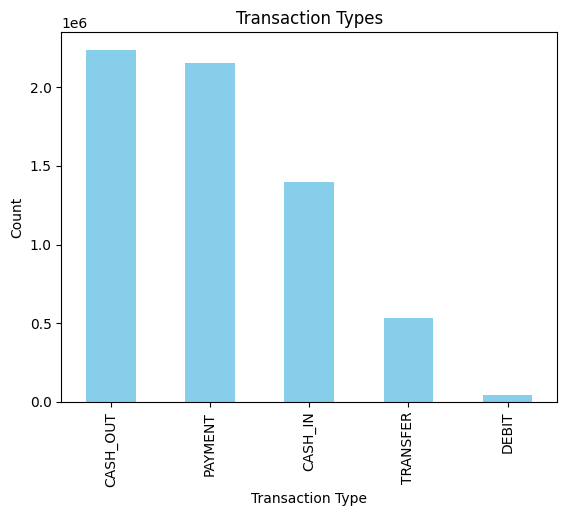

In [ ]:
data["type"].value_counts().plot(kind="bar", title="Transaction Types", color = "skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

##Percentage of Fraud in each Type

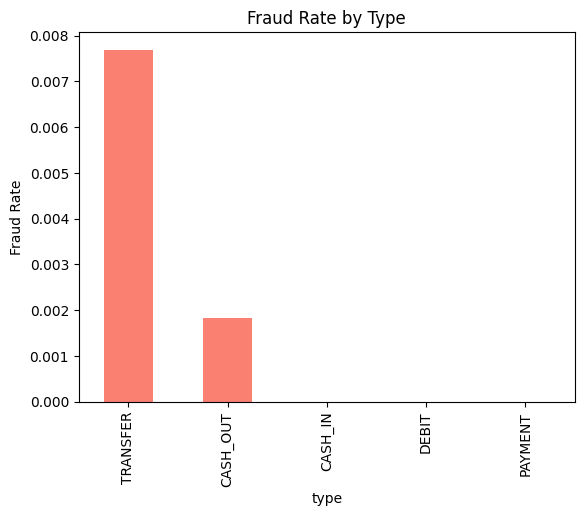

In [ ]:
fraud_by_type = data.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [ ]:
data["amount"].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


##Amount distribution

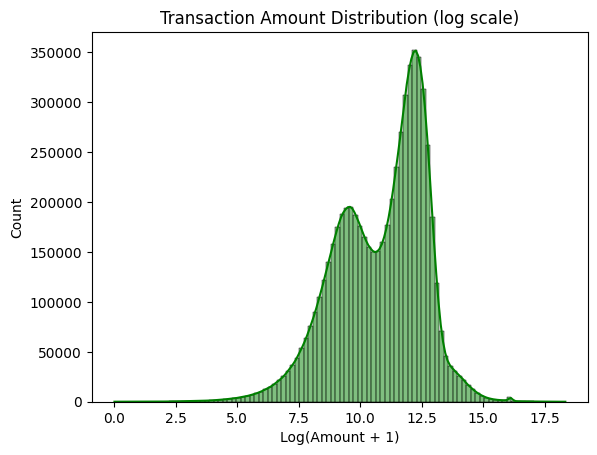

In [ ]:
sns.histplot(np.log1p(data["amount"]), bins=100, kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

## Fraud vs Amount (filtered under 50k)

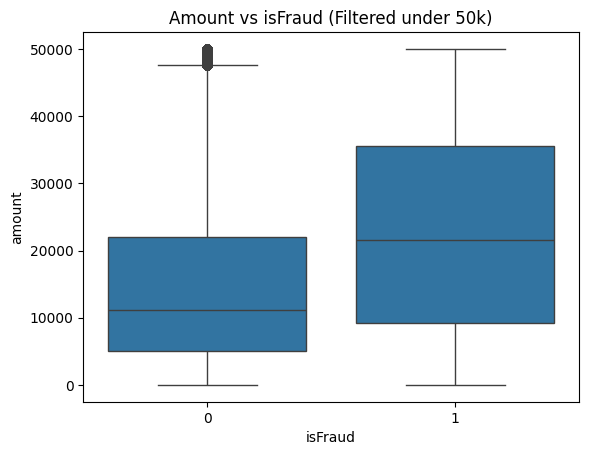

In [ ]:
sns.boxplot(data=data[data["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [ ]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

#Feature Engineering

In [ ]:
data["balanceDiffOrig"] = data["oldbalanceOrg"] - data["newbalanceOrig"]
data["balanceDiffDest"] = data["newbalanceDest"] - data["oldbalanceDest"]

##Checking Negative Amount After Difference Between Orignial and Old balance

In [ ]:
#If the difference is negative, it means the sender’s new balance is higher than the old balance, which is not logical (unless there was an unexpected credit).
(data["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [ ]:
#A negative difference means the destination’s new balance is less than the old balance, which is also not logical (receiver should gain or remain the same).
(data["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [ ]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


## Fraud over time (step variable)

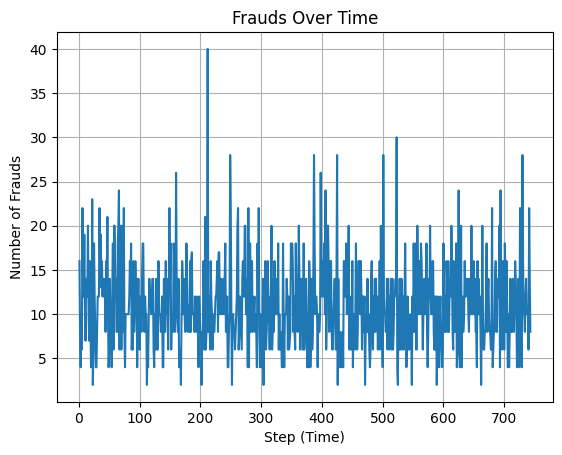

In [ ]:
frauds_per_step = data[data["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [ ]:
#From the Graph Fraud is not actually time dependent
data.drop(columns="step", inplace=True)

In [ ]:
data.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
top_senders = data["nameOrig"].value_counts()
top_senders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
...,...
C1567523029,1
C644777639,1
C1256645416,1


In [ ]:
Top_receivers = data["nameDest"].value_counts()
Top_receivers

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
...,...
M367627425,1
M1902904124,1
M242332837,1


In [ ]:
fraud_users = data[data["isFraud"]==1]["nameOrig"].value_counts()
fraud_users

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
...,...
C1364127192,1
C467632528,1
C1334405552,1


In [ ]:
fraud_types = data[data["type"].isin(["TRANSFER","CASH_OUT"])]
fraud_types

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


In [ ]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,2237500
TRANSFER,532909


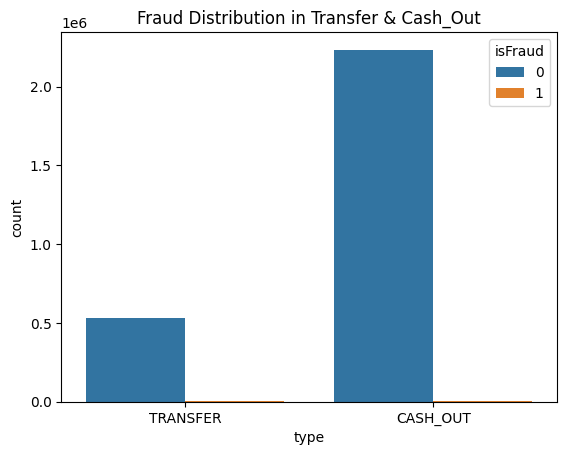

In [ ]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [ ]:
corr = data[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


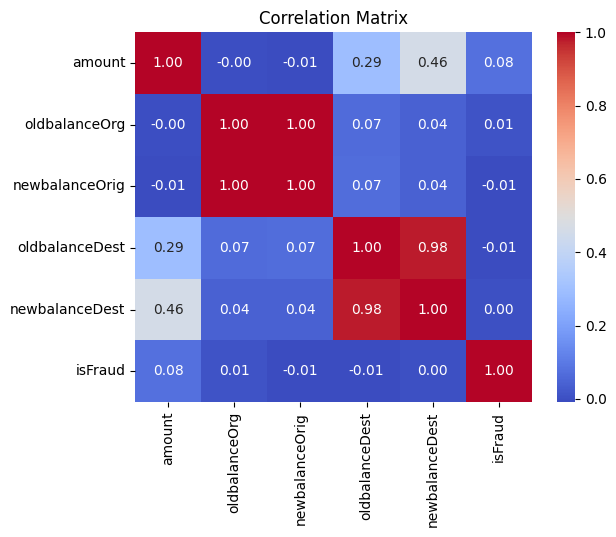

In [ ]:
sns.heatmap(corr,annot=True,cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#the sender had money before making the transaction.
#the sender’s account was emptied completely.
#the money was either transferred to another account or withdrawn as cash.
zero_after_transfer = data[
    (data["oldbalanceOrg"] > 0) &
    (data["newbalanceOrig"] == 0) &
    (data["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

1188074

In [ ]:
zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


In [ ]:
data["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
df_model = data.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,9839.64,0.00
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,1864.28,0.00
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,181.00,0.00
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,181.00,-21182.00
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,11668.14,0.00
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,339682.13,339682.13
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,6311409.28,0.00
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,6311409.28,6311409.27
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,850002.52,0.00


In [ ]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

#Data Preprocessing

In [ ]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder= "drop"
)

#Supervised Models (Logistic Regression & Random Forest)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

log_reg = LogisticRegression(
    class_weight=None,
    max_iter=2000,
    solver="lbfgs",
    random_state=42
)

rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    # ("to_dense", to_dense),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("clf", rf),
])



logreg_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    # ("to_dense", to_dense),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("clf", log_reg),
])

In [ ]:
#Logistic Regression
logreg_pipe.fit(X_train, y_train)

#Random Forest
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                        random_state=42))])

#Unsupervised Model (Isolation Forest)

In [ ]:
# --- Step 1: Preprocess data ---
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# --- Step 2: Train Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_preprocessed)

# --- Step 3: Get anomaly scores ---
anomaly_scores = -iso_forest.decision_function(X_test_preprocessed)
# higher = more anomalous

# --- Step 4: Tune threshold using Precision-Recall tradeoff ---
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

# --- Step 5: Convert scores into predictions ---
y_pred_iso = (anomaly_scores >= best_threshold).astype(int)

#Autoencoder

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


# --- Step 2: Define Autoencoder ---
input_dim = X_train_preprocessed.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
encoder = Dense(16, activation="relu")(encoder)  # bottleneck

decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(decoder)
decoder = Dense(input_dim, activation="linear")(decoder)  # reconstruct input

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

# --- Step 3: Train Autoencoder only on majority class (non-fraud = 0) ---
X_train_majority = X_train_preprocessed[y_train == 0]

history = autoencoder.fit(
    X_train_majority, X_train_majority,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

# --- Step 4: Compute reconstruction errors ---
reconstructions = autoencoder.predict(X_test_preprocessed)
mse = np.mean(np.square(X_test_preprocessed - reconstructions), axis=1)

# --- Step 5: Set threshold for anomaly detection ---
threshold = np.percentile(mse, 95)  # top 5% as anomalies
y_pred_autoenc = (mse > threshold).astype(int)

Epoch 1/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - loss: 0.0105 - val_loss: 3.3885e-04
Epoch 2/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 86s 3ms/step - loss: 5.4420e-04 - val_loss: 8.8714e-05
Epoch 3/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - loss: 8.9203e-04 - val_loss: 1.7101e-04
Epoch 4/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 98s 4ms/step - loss: 5.5424e-04 - val_loss: 1.1874e-04
Epoch 5/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 6.3796e-04 - val_loss: 9.3991e-05
Epoch 6/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - loss: 4.2090e-04 - val_loss: 3.4108e-05
Epoch 7/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 3.4290e-04 - val_loss: 5.0317e-05
Epoch 8/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - loss: 2.5593e-04 - val_loss: 5.2712e-05
Epoch 9/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - loss: 1.8882e-04 - val_loss: 8.8690e-05
Epoch 10/20
15638/15638 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 1.8184e-04 - val_loss: 1.7138e-04
Epoch 11/20
1

#Evaluation

In [ ]:
logreg_pred = logreg_pipe.predict(X_test)
rf_pred = rf_pipe.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, logreg_pred))

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("Isolation Forest Classification Report:")
print(classification_report(y_test, y_pred_iso))

print("Autoencoder Classification Report:")
print(classification_report(y_test, y_pred_autoenc))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.96      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.62      0.96      0.76      2464

    accuracy                           1.00   1908786
   macro avg       0.81      0.98      0.88   1908786
weighted avg       1.00      1.00      1.00   1908786

Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1906322
           1       0.01      0.07      0.02      2464

    accuracy                           0.99   1908786
   macro

#Visualization

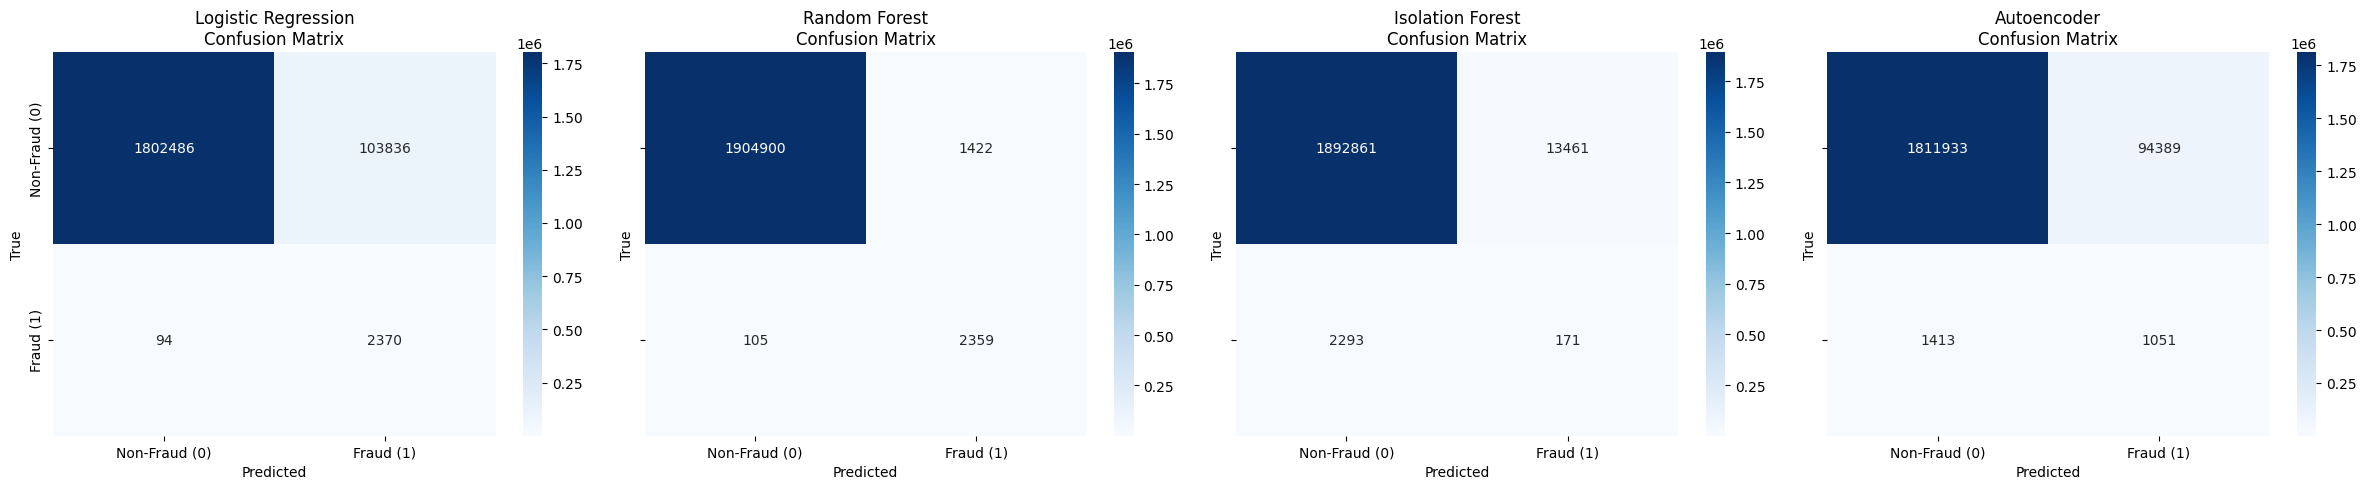

/tmp/ipython-input-306459790.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=values, ax=ax, palette="Blues_d")
/tmp/ipython-input-306459790.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=values, ax=ax, palette="Blues_d")
/tmp/ipython-input-306459790.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=values, ax=ax, palette="Blues_d")
/tmp/ipython-input-306459790.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

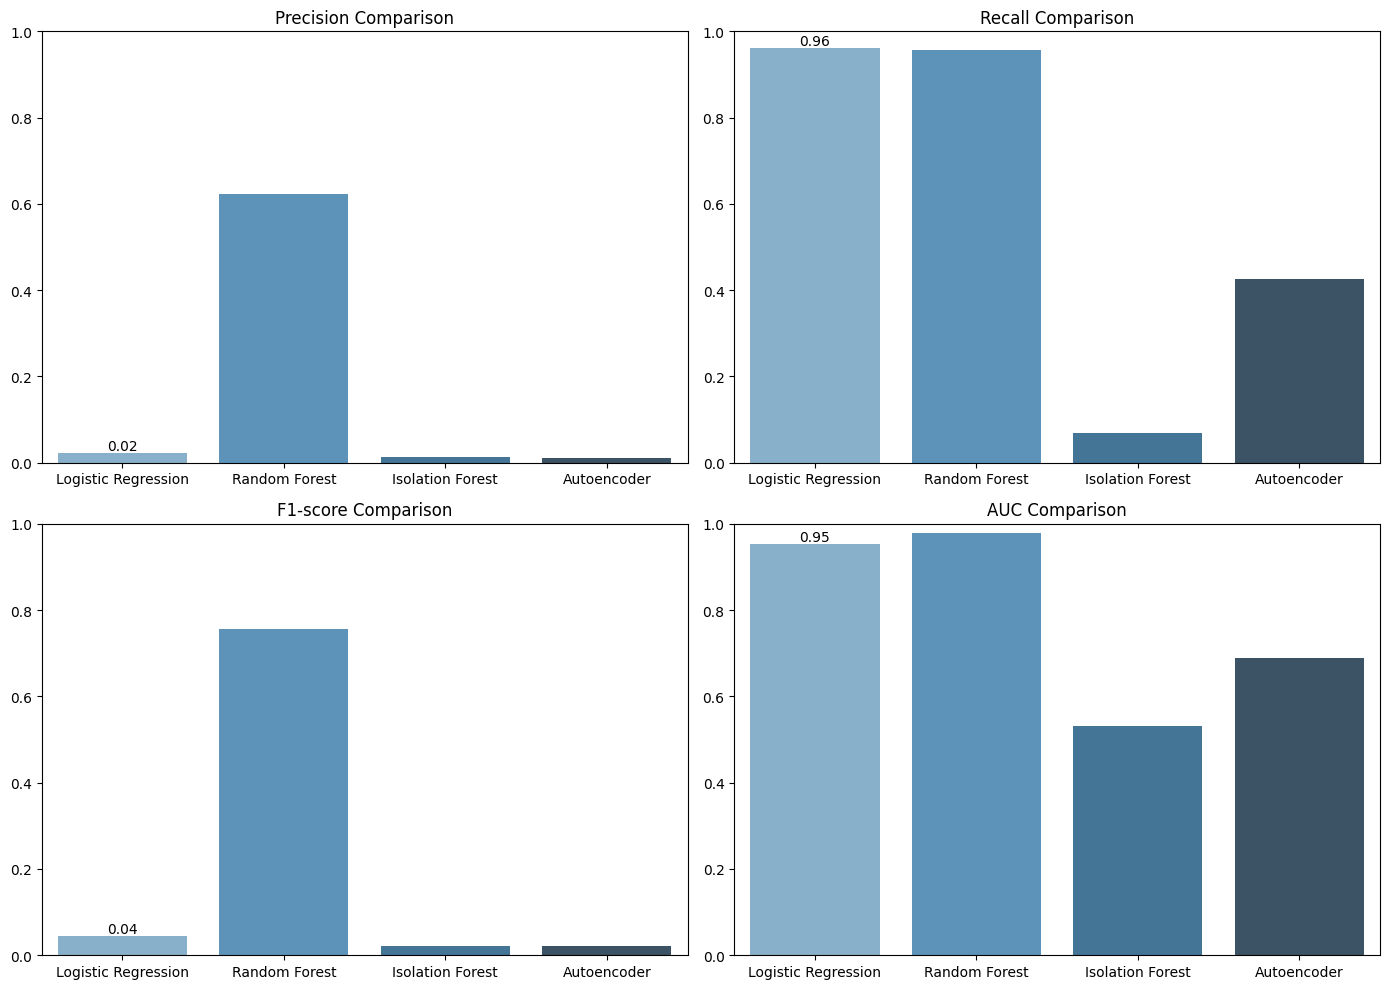

In [ ]:
# --- Collect metrics ---
models = ["Logistic Regression", "Random Forest", "Isolation Forest", "Autoencoder"]
preds = [logreg_pred, rf_pred, y_pred_iso, y_pred_autoenc]

metrics = {
    "Precision": [],
    "Recall": [],
    "F1-score": [],
    "AUC": []
}

for pred in preds:
    metrics["Precision"].append(precision_score(y_test, pred))
    metrics["Recall"].append(recall_score(y_test, pred))
    metrics["F1-score"].append(f1_score(y_test, pred))
    metrics["AUC"].append(roc_auc_score(y_test, pred))

# --- Plot Confusion Matrices ---
cms = [confusion_matrix(y_test, p) for p in preds]

fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)

for ax, cm, title in zip(axes, cms, models):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
                yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
    ax.set_title(f"{title}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

# --- Plot Metrics Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (metric_name, values) in zip(axes.flat, metrics.items()):
    sns.barplot(x=models, y=values, ax=ax, palette="Blues_d")
    ax.set_title(f"{metric_name} Comparison")
    ax.set_ylim(0, 1)
    ax.bar_label(ax.containers[0], fmt="%.2f")

plt.tight_layout()
plt.show()

In [ ]:
# Scores
print("Logistic Regression Score:", logreg_pipe.score(X_test, y_test) * 100)
print("Random Forest Score:", rf_pipe.score(X_test, y_test) * 100)

iso_score = accuracy_score(y_test, y_pred_iso) * 100
print(f"Isolation Forest Score: {iso_score}")
auto_acc = accuracy_score(y_test, y_pred_autoenc) * 100
print(f"Autoencoder Classification Report: {auto_acc}")

Logistic Regression Score: 94.55517800319156
Random Forest Score: 99.9200015088124
Isolation Forest Score: 99.17465865738747
Autoencoder Classification Report: 94.98099839374345
